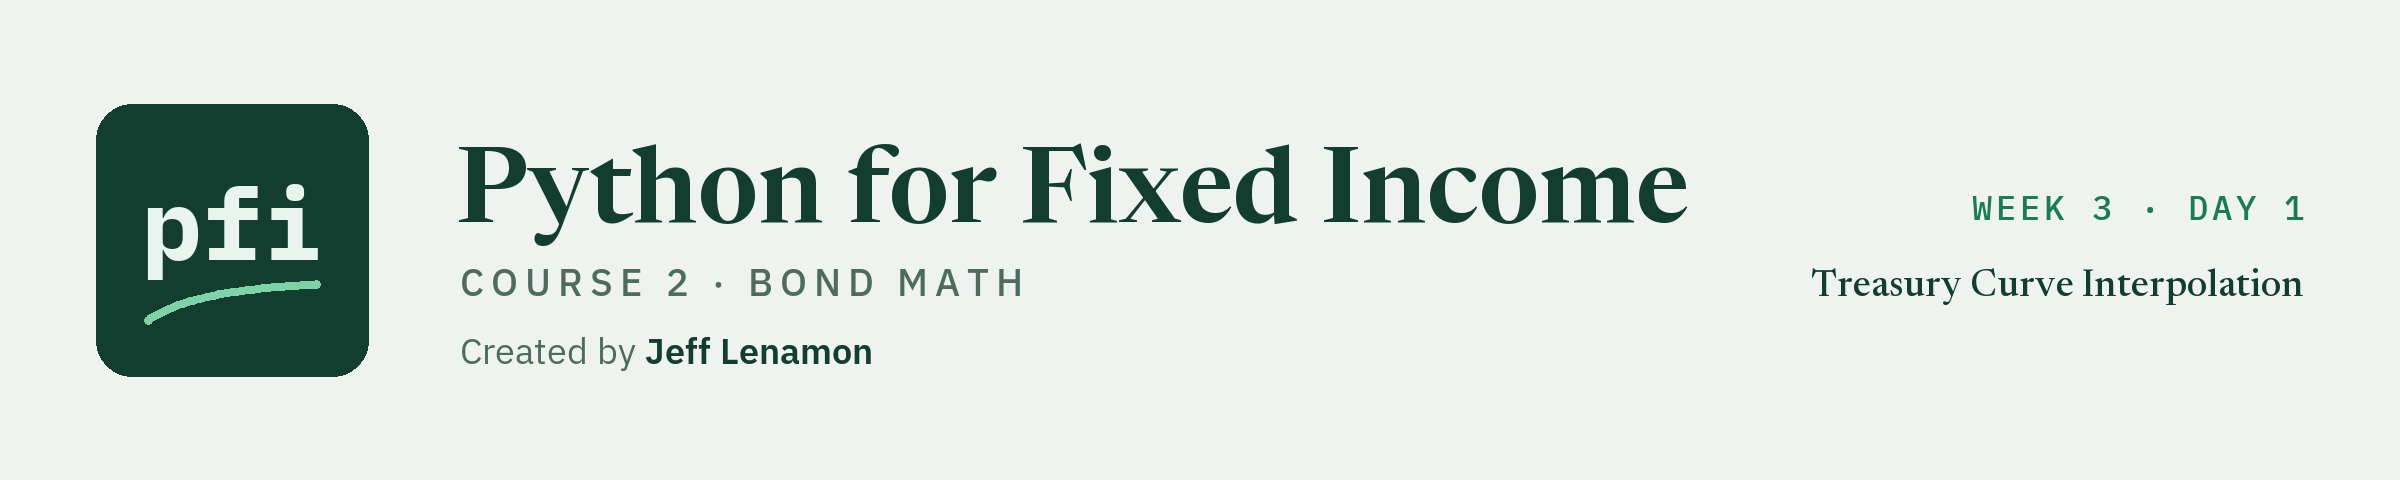

# Treasury Curve Interpolation

Week 3, Day 1. Week 3 starts with the curve. A Treasury curve is a short list of tenors and yields; a yield between two tenors comes from a straight line. Today you read the real Treasury par curve of 30 September 2026, interpolate it by hand and with your own `interpolate_yield`, check it against `numpy.interp` and Excel's `FORECAST.LINEAR`, and meet the invented curve the holdings file was built on.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course2_bond_math/week3/day1/11_treasury_curve_interpolation.ipynb)

Week 2 ended with the September book reproduced from first principles: price, yield, accrued interest, duration, DV01, and convexity for every bond in `holdings.csv`. Week 3 asks a credit question of the same book: **how much yield does each bond pay over Treasuries?** That is the spread, and day 12 computes it.

A spread needs a Treasury yield at the bond's own maturity. A bond with 6.4 years left needs the Treasury yield at 6.4 years. Treasury does not publish one. It publishes a short list of tenors, 1 month, 3 months, 1 year, 5 years, 7 years, and so on, and every maturity in between has to be read off a line drawn through them. That is **curve interpolation**, and it is today's job.

Two curves appear today, and they do different jobs:

1. **The real Treasury par curve of 30 September 2026**, from Treasury's published file. It teaches the method. It is described only, and never used to compute a spread, because the holdings file was not built on it.
2. **An invented curve at ten tenors**, the curve the holdings file's yields were built on. Days 12 to 14 use it.

Today you will:

1. Read the Treasury curve of 30 September 2026 and turn its column labels, such as `3 Mo` and `10 Yr`, into years.
2. Interpolate between two tenors by hand, and find the two tenors around any maturity.
3. Add `interpolate_yield` to your module, with flat ends and a check that the tenors ascend.
4. Check it against `numpy.interp`, and see what `numpy.interp` does not check.
5. Meet the invented curve the holdings were built on, charted beside the real one.
6. Measure how far the straight lines sit from the smooth curve they are drawn through.

The holdings, issuers, and the ten-tenor curve are invented. The Treasury yields are real published figures, and nothing here says where they are going or what they mean.

The setup cell is the same as every day's. Then the next cell writes `bondmath.py` and `test_bondmath.py` as they stood at the end of day 10.

Q. Set up today's work folder and copy the Excel reference files into it.

In [1]:
# modules that come with Python: folders and files, the temp folder, running programs, reloading a module
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# pytest runs the tests. A Colab runtime may not have it.
try:
    import pytest
except ImportError:
    raise RuntimeError("pytest is not installed. Run  !pip install pytest  in a new cell, then run this cell again.") from None

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "bondmath_excel_reference.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course2_11_"))
os.chdir(work)

# 3. copy the two Excel reference files into the work folder
for name in ["bondmath_excel_reference.csv", "bondmath_excel_reference_tvm.csv"]:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Reference files copied from: {'GitHub' if on_github else 'the data folder of the course repo'}")
print(f"pytest version: {pytest.__version__}")

Work folder: pfi_course2_11_q620lasz, in your temp folder
Reference files copied from: the data folder of the course repo
pytest version: 9.1.1


Q. Write `bondmath.py` and `test_bondmath.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100


def yield_from_price(coupon_pct: float, price: float, years: float, frequency: int = 2) -> float:
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

    Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
    Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
    The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price_from_yield(coupon_pct, mid_pct, years, frequency) > price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def add_months(d: date, months: int) -> date:
    """Move a date by whole months, keeping the day of the month where the month allows it.

    Units: d is a date, months a whole number (negative moves back).
    Convention: the day is clamped to the length of the new month, so 31 August minus 6 months is
    28 February (29 February in a leap year). Excel: =EDATE(d, months)
    """
    # count months from year 0 so the year and month come out of one division
    month_index = d.year * 12 + (d.month - 1) + months
    year, month_zero_based = divmod(month_index, 12)
    month = month_zero_based + 1
    # the number of days in the new month
    days_in_month = calendar.monthrange(year, month)[1]
    # keep the day, or use the last day of a shorter month
    return date(year, month, min(d.day, days_in_month))


def coupon_dates(settlement: date, maturity: date, frequency: int = 2) -> list[date]:
    """The previous coupon date, then every coupon date left through maturity.

    Units: dates. Convention: coupon dates are counted back from maturity in steps of 12 / frequency
    months, each one computed from maturity directly, so a 31st never drifts to the 28th. If maturity
    is the last day of its month, every coupon date is the last day of its month (Excel's rule).
    The previous coupon date is the last one on or before settlement.
    So [0] is Excel's COUPPCD, [1] is COUPNCD, and len - 1 is COUPNUM.
    """
    # stop on bad input
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # months between coupons
    step_months = 12 // frequency
    # does the bond mature on the last day of a month?
    month_end = maturity.day == calendar.monthrange(maturity.year, maturity.month)[1]
    dates = []
    k = 0
    while True:
        # coupon k steps back from maturity, computed from maturity itself
        coupon_date = add_months(maturity, -k * step_months)
        if month_end:
            # the month-end rule: move to the last day of that month
            last_day = calendar.monthrange(coupon_date.year, coupon_date.month)[1]
            coupon_date = date(coupon_date.year, coupon_date.month, last_day)
        dates.append(coupon_date)
        # stop once we reach the previous coupon date
        if coupon_date <= settlement:
            break
        k += 1
    # earliest first
    dates.reverse()
    return dates


def days_30_360(start: date, end: date) -> int:
    """Days from start to end on the US 30/360 basis, as Excel's COUPDAYBS and YEARFRAC(..., 0) count them.

    Units: dates in, whole days out. Every month counts as 30 days and every year as 360.
    Convention, with D1 the start day and D2 the end day:
    1. If start is the last day of February, D1 = 30.
    2. If start and end are both the last day of February, D2 = 30.
    3. If D1 is 31, D1 = 30.
    4. If D2 is 31 and the start day was 30 or 31, D2 = 30. (Excel looks at the start date's own
       day here, so a start on 28 February and an end on the 31st keeps D2 = 31.)
    Days = 360 x (Y2 - Y1) + 30 x (M2 - M1) + (D2 - D1).
    Excel's DAYS360 uses different February rules and is not the same count.
    """
    d1, d2 = start.day, end.day
    start_is_feb_end = start.month == 2 and start.day == calendar.monthrange(start.year, 2)[1]
    end_is_feb_end = end.month == 2 and end.day == calendar.monthrange(end.year, 2)[1]
    # rule 1: the last day of February counts as the 30th
    if start_is_feb_end:
        d1 = 30
    # rule 2: both dates on the last day of February
    if start_is_feb_end and end_is_feb_end:
        d2 = 30
    # rule 3: a 31st start counts as the 30th
    if start.day == 31:
        d1 = 30
    # rule 4: a 31st end counts as the 30th when the start day was 30 or 31
    if end.day == 31 and start.day >= 30:
        d2 = 30
    return 360 * (end.year - start.year) + 30 * (end.month - start.month) + (d2 - d1)


def coupon_period_days(settlement: date, maturity: date, frequency: int = 2,
                       basis: str = "30/360") -> tuple[int, int, int]:
    """Day counts of the coupon period that holds settlement: (A, E, DSC).

    Units: whole days.
    A is days from the previous coupon to settlement (Excel COUPDAYBS).
    E is days in the coupon period: 360 / frequency under 30/360 (Excel COUPDAYS), and the actual days
    from the previous to the next coupon under ACT/ACT.
    DSC is days from settlement to the next coupon, as Excel's PRICE uses it: E - A under 30/360
    (this can differ from COUPDAYSNC near the end of February), actual days under ACT/ACT.
    """
    # stop on a basis the course does not use (coupon_dates checks frequency and dates)
    if basis not in ("30/360", "ACT/ACT"):
        raise ValueError(f'basis must be "30/360" or "ACT/ACT", not {basis!r}')
    # the previous and next coupon dates
    dates = coupon_dates(settlement, maturity, frequency)
    previous_coupon, next_coupon = dates[0], dates[1]
    if basis == "30/360":
        # 30/360: A by the 30/360 rules, a fixed period length, and DSC as what is left of it
        days_accrued = days_30_360(previous_coupon, settlement)
        days_in_period = 360 // frequency
        days_to_next = days_in_period - days_accrued
    else:
        # ACT/ACT: every count is actual calendar days
        days_accrued = (settlement - previous_coupon).days
        days_in_period = (next_coupon - previous_coupon).days
        days_to_next = (next_coupon - settlement).days
    return days_accrued, days_in_period, days_to_next


def accrued_interest(settlement: date, maturity: date, coupon_pct: float, frequency: int = 2,
                     basis: str = "30/360") -> float:
    """Accrued interest the buyer pays the seller, per 100 of face.

    Units: coupon_pct in percent a year; the result is per 100 of face.
    Convention: coupon_pct / frequency x A / E, with A and E from coupon_period_days.
    Excel (30/360): =100*coupon_pct/100/frequency*COUPDAYBS(...)/COUPDAYS(...)
    """
    # A and E for this settlement
    days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
    # one coupon, times the share of the period that has passed
    return coupon_pct / frequency * days_accrued / days_in_period


def price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
          basis: str = "30/360") -> float:
    """Clean price per 100 of face on any settlement date, as Excel's PRICE.

    Units: coupon_pct and yield_pct in percent a year; the result is a clean price per 100 of face.
    Convention: yield compounded `frequency` times a year. w = DSC / E is the part of a period left
    until the next coupon. Dirty price = sum over the N coupons left of CF_k / (1 + y/f) ** (w + k).
    In the final coupon period (N = 1) Excel uses simple interest: dirty = (100 + CF) / (1 + w x y/f).
    Clean = dirty - accrued interest.
    Excel: =PRICE(settlement, maturity, coupon_pct/100, yield_pct/100, 100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    days_accrued, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    # coupons left, the fraction of a period to the next one, the period yield, and one coupon
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    if coupons_left == 1:
        # final period: simple interest on the last coupon and the face
        dirty = (100 + coupon) / (1 + w * period_yield)
    else:
        dirty = 0.0
        for k in range(coupons_left):
            # the last cash flow also returns the face
            cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
            dirty += cash_flow / (1 + period_yield) ** (w + k)
    # the quote is clean: take off the accrued interest
    return dirty - accrued_interest(settlement, maturity, coupon_pct, frequency, basis)


def dirty_price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                basis: str = "30/360") -> float:
    """Dirty (full, invoice) price per 100 of face: the clean price plus accrued interest.

    Units and convention as price(). Excel: =PRICE(...) + the accrued formula.
    """
    # clean price plus accrued interest
    return (price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
            + accrued_interest(settlement, maturity, coupon_pct, frequency, basis))


def yield_to_maturity(settlement: date, maturity: date, coupon_pct: float, clean_price: float,
                      frequency: int = 2, basis: str = "30/360") -> float:
    """Yield in percent from a clean price on any settlement date, by bisection, as Excel's YIELD x 100.

    Units: coupon_pct in percent a year, clean_price per 100 of face; the result is in percent a year.
    Convention: the yield at which price() equals clean_price. The search runs between -5 and 100
    percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Final coupon period: Excel's YIELD uses a formula instead of a search, with DSR, the days from
    settlement to maturity, counted by days_30_360 under 30/360 (actual days under ACT/ACT):
    yield = ((100 + CF) - dirty) / dirty x frequency x E / DSR. Under 30/360 DSR can differ from the
    E - A that PRICE uses, so in those cases YIELD does not return the yield PRICE was given.
    Excel: =YIELD(settlement, maturity, coupon_pct/100, clean_price, 100, frequency, basis)*100
    """
    # final coupon period: Excel's formula (coupon_dates and coupon_period_days check the inputs)
    if len(coupon_dates(settlement, maturity, frequency)) - 1 == 1:
        days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
        if basis == "30/360":
            days_to_maturity = days_30_360(settlement, maturity)
        else:
            days_to_maturity = (maturity - settlement).days
        coupon = coupon_pct / frequency
        # the dirty price paid, and what comes back at maturity
        paid = clean_price + coupon * days_accrued / days_in_period
        received = 100 + coupon
        # the simple return over the days left, made annual, in percent
        return (received - paid) / paid * frequency * days_in_period / days_to_maturity * 100
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price(settlement, maturity, coupon_pct, low_pct, frequency, basis)
    lowest_price = price(settlement, maturity, coupon_pct, high_pct, frequency, basis)
    if not lowest_price <= clean_price <= highest_price:
        raise ValueError(f"price {clean_price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price(settlement, maturity, coupon_pct, mid_pct, frequency, basis) > clean_price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def macaulay_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Macaulay duration in years: the present-value weighted average time of the cash flows.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: t_k = (w + k) / frequency years, PV_k = CF_k / (1 + y/f) ** (w + k), and
    duration = sum of t_k x PV_k / sum of PV_k. In the final period this is DSC / E / frequency.
    Excel: =DURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, weighted_time = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow, its time in years, and its present value
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        pv = cash_flow / (1 + period_yield) ** (w + k)
        total_pv += pv
        weighted_time += time_years * pv
    # the weighted average time
    return weighted_time / total_pv


def modified_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Modified duration in years: the percent price change for a 1-point (100 bp) change in yield.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: Macaulay duration / (1 + y / frequency), with y = yield_pct / 100.
    Excel: =MDURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # divide Macaulay duration by one plus the period yield
    period_yield = yield_pct / 100 / frequency
    return macaulay_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis) / (1 + period_yield)


def dv01(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
         basis: str = "30/360") -> float:
    """DV01: price points per 100 of face for a 1 basis point fall in yield, positive for a long position.

    Units: coupon_pct and yield_pct in percent a year; the result is in price points per 100 of face per bp.
    Convention: modified duration x dirty price x 0.0001. Position DV01 in dollars = dv01 x par / 100.
    Excel: =MDURATION(...)*(PRICE(...)+accrued)/10000
    """
    # modified duration times the dirty price, for one basis point (0.0001 as a decimal)
    duration_years = modified_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    return duration_years * full_price * 0.0001


def convexity(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
              basis: str = "30/360") -> float:
    """Convexity in years squared, unscaled (not divided by 100 or by 2).

    Units: coupon_pct and yield_pct in percent a year; the result is in years squared.
    Convention: (1 / P) x sum of CF_k x t_k x (t_k + 1/f) / (1 + y/f) ** (f t_k + 2), where
    t_k = (w + k) / f and P is the sum of the discounted cash flows. Price change estimate:
    dP / P = -D_mod x dy + 0.5 x convexity x dy ** 2, with dy in decimal.
    Excel has no convexity function; the check is a central difference on three PRICE cells.
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, curvature = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow and its time in years
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        # its present value, and its term in the convexity sum
        total_pv += cash_flow / (1 + period_yield) ** (w + k)
        curvature += (cash_flow * time_years * (time_years + 1 / frequency)
                      / (1 + period_yield) ** (frequency * time_years + 2))
    # divide by the price
    return curvature / total_pv

Writing bondmath.py


In [3]:
%%writefile test_bondmath.py
"""Tests for bondmath.py.

Every expected value comes from Excel: the two reference CSV files in this folder, or a small hand
table whose values those files confirm. Run from this folder with:  python -m pytest
"""
import csv
import math  # used from week 3
from datetime import date  # used from week 2
from pathlib import Path

import pytest

import bondmath

# the reference files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_rows(file_name: str) -> list[dict]:
    """Read a reference CSV from this folder: one dict per row, every value a string."""
    with open(HERE / file_name, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


TVM = read_rows("bondmath_excel_reference_tvm.csv")


def tvm_rows(function: str) -> list[dict]:
    """The week 1 reference rows for one Excel function, for example "FV"."""
    rows = [row for row in TVM if row["function"] == function]
    assert rows, f"no {function} rows in the reference file"
    return rows


def test_future_value_matches_excel_fv():
    for row in tvm_rows("FV"):
        # the inputs, in course units
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.future_value(amount, rate_pct, years, frequency)
        # Excel's FV, with the amount entered as -amount, is positive
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_matches_excel_pv():
    for row in tvm_rows("PV"):
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.present_value(amount, rate_pct, years, frequency)
        # Excel's PV of a positive amount is negative (money paid now), so compare with minus the Excel value
        assert result == pytest.approx(-float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_undoes_future_value():
    for frequency in (1, 2, 4):
        # grow 100 for 3 years at 5 percent, then discount it back
        grown = bondmath.future_value(100, 5.0, 3, frequency)
        assert bondmath.present_value(grown, 5.0, 3, frequency) == pytest.approx(100, abs=1e-9)


REFERENCE = read_rows("bondmath_excel_reference.csv")


def test_cash_flows_count_and_final_flow():
    flows = bondmath.cash_flows(6.0, 5, 2)
    # 5 years of half-year coupons is 10 cash flows
    assert len(flows) == 10
    # the first is a 3.00 coupon after half a year, the last is the coupon plus the face at 5 years
    assert flows[0] == pytest.approx((0.5, 3.0))
    assert flows[-1] == pytest.approx((5.0, 103.0))


def test_cash_flows_raises_on_part_periods():
    # 2.3 years is not a whole number of half years, so cash_flows must stop with a ValueError
    try:
        bondmath.cash_flows(6.0, 2.3, 2)
    except ValueError:
        return
    assert False, "cash_flows accepted 2.3 years at frequency 2"


def test_price_from_yield_matches_excel():
    # Excel's -PV with a coupon: a bond priced on a coupon date
    for row in tvm_rows("PV_BOND"):
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["rate_pct"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]
    # Excel's PRICE on the rows that settle on a coupon date (no days accrued)
    coupon_date_rows = [row for row in REFERENCE if row["coupdaybs"] == "0"]
    assert coupon_date_rows, "no coupon-date rows in the reference file"
    for row in coupon_date_rows:
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["yield_pct"]), years, frequency)
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_convert_yield_matches_excel_effect_and_nominal():
    # EFFECT restates a rate compounded `frequency` times a year as an annually compounded rate
    for row in tvm_rows("EFFECT"):
        result = bondmath.convert_yield(float(row["rate_pct"]), int(row["frequency"]), 1)
        # Excel returns a decimal, bondmath a percent
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]
    # NOMINAL goes the other way: from annual compounding to `frequency` times a year
    for row in tvm_rows("NOMINAL"):
        result = bondmath.convert_yield(float(row["rate_pct"]), 1, int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]


def test_convert_yield_round_trip():
    # semiannual to quarterly and back gives the yield we started with
    quarterly = bondmath.convert_yield(6.0, 2, 4)
    assert bondmath.convert_yield(quarterly, 4, 2) == pytest.approx(6.0, abs=1e-12)


def test_yield_from_price_matches_excel():
    # Excel's RATE, times the frequency, is the annual yield as a decimal
    for row in tvm_rows("RATE"):
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-6), row["case_id"]
    # Excel's YIELD on the coupon-date rows, already in percent in the reference file
    for row in REFERENCE:
        if row["coupdaybs"] != "0":
            continue
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]), years, frequency)
        assert result == pytest.approx(float(row["yield_pct_from_price"]), abs=1e-6), row["case_id"]


def test_yield_raises_outside_bracket():
    # no yield between -5 and 100 percent gives a price of 1,000 or of 0.01
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 1000.0, 5, 2)
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 0.01, 5, 2)


def test_yield_round_trip():
    # price a bond from a yield, then solve the yield back from that price
    bond_price = bondmath.price_from_yield(5.25, 6.1, 7, 2)
    assert bondmath.yield_from_price(5.25, bond_price, 7, 2) == pytest.approx(6.1, abs=1e-8)


def test_par_bond_prices_at_100():
    # a coupon equal to the yield prices at 100 for every frequency and term
    for frequency in (1, 2, 4):
        for years in (1, 2, 5, 10, 30):
            assert bondmath.price_from_yield(5.5, 5.5, years, frequency) == pytest.approx(100, abs=1e-9)


def test_price_falls_as_yield_rises():
    # price a 10-year 6 percent bond at yields from 2 to 12 percent
    prices = [bondmath.price_from_yield(6.0, yield_pct, 10, 2) for yield_pct in (2, 4, 6, 8, 10, 12)]
    # every price is below the one before it
    for earlier, later in zip(prices, prices[1:]):
        assert later < earlier


def test_add_months_clamps_to_month_end():
    # 31 August back 6 months: 28 February, or 29 February in a leap year
    assert bondmath.add_months(date(2031, 8, 31), -6) == date(2031, 2, 28)
    assert bondmath.add_months(date(2032, 8, 31), -6) == date(2032, 2, 29)
    # 31 January forward 1 month
    assert bondmath.add_months(date(2027, 1, 31), 1) == date(2027, 2, 28)
    # a day every month has is kept, across a year end
    assert bondmath.add_months(date(2026, 11, 15), 3) == date(2027, 2, 15)


def test_coupon_dates_match_excel():
    for row in REFERENCE:
        settlement, maturity = date.fromisoformat(row["settlement"]), date.fromisoformat(row["maturity"])
        dates = bondmath.coupon_dates(settlement, maturity, int(row["frequency"]))
        # [0] is COUPPCD, [1] is COUPNCD, and the number of dates after [0] is COUPNUM
        assert dates[0] == date.fromisoformat(row["couppcd"]), row["case_id"]
        assert dates[1] == date.fromisoformat(row["coupncd"]), row["case_id"]
        assert len(dates) - 1 == int(row["coupnum"]), row["case_id"]


BASIS = {"0": "30/360", "1": "ACT/ACT"}  # Excel's basis number to bondmath's name


def bond_inputs(row: dict) -> tuple:
    """settlement, maturity, coupon_pct, yield_pct, frequency, basis from a reference row, in bondmath's units."""
    return (date.fromisoformat(row["settlement"]), date.fromisoformat(row["maturity"]),
            float(row["coupon_pct"]), float(row["yield_pct"]), int(row["frequency"]), BASIS[row["basis"]])


def test_days_30_360_rule_cases():
    # (start, end, expected days, the Excel function that confirms the value)
    cases = [
        (date(2026, 8, 16), date(2026, 9, 30), 44, "COUPDAYBS"),    # no rule applies
        (date(2027, 2, 28), date(2027, 3, 1), 1, "COUPDAYBS"),      # rule 1: last day of February counts as 30
        (date(2027, 2, 28), date(2028, 2, 29), 360, "YEARFRAC"),    # rule 2: both on the last day of February
        (date(2026, 8, 31), date(2026, 9, 30), 30, "COUPDAYBS"),    # rule 3: a 31st start counts as 30
        (date(2026, 7, 30), date(2026, 10, 31), 90, "COUPDAYBS"),   # rule 4: a 31st end after a 30th start
        (date(2026, 10, 15), date(2026, 10, 31), 16, "COUPDAYBS"),  # a 31st end after a 15th start stays 31
        (date(2027, 2, 28), date(2027, 3, 31), 31, "COUPDAYBS"),    # rule 1, and the 31st end stays 31
        (date(2026, 11, 15), date(2027, 2, 28), 103, "COUPDAYBS"),  # an end on 28 February is not changed
    ]
    for start, end, expected, source in cases:
        assert bondmath.days_30_360(start, end) == expected, (start, end)
        if source == "COUPDAYBS":
            # the same pair of dates appears in the reference file as previous coupon and settlement
            matches = [row for row in REFERENCE if row["basis"] == "0" and row["couppcd"] == start.isoformat()
                       and row["settlement"] == end.isoformat()]
            assert matches, f"no reference row with previous coupon {start} and settlement {end}"
            assert int(matches[0]["coupdaybs"]) == expected
        # the YEARFRAC value, YEARFRAC(start, end, 0) x 360 = 360, was checked in Excel by the reference tool


def test_coupon_period_days_match_excel():
    for row in REFERENCE:
        settlement, maturity, _, _, frequency, basis = bond_inputs(row)
        days_accrued, days_in_period, days_to_next = bondmath.coupon_period_days(settlement, maturity, frequency, basis)
        # A is COUPDAYBS under both bases
        assert days_accrued == int(row["coupdaybs"]), row["case_id"]
        if basis == "30/360":
            # E is COUPDAYS, and PRICE uses DSC = E - A
            assert days_in_period == int(row["coupdays"]), row["case_id"]
            assert days_to_next == int(row["coupdays"]) - int(row["coupdaybs"]), row["case_id"]
        else:
            # E is the actual length of the period, which PRICE uses (Excel's COUPDAYS with basis 1 can differ)
            period_start, period_end = date.fromisoformat(row["couppcd"]), date.fromisoformat(row["coupncd"])
            assert days_in_period == (period_end - period_start).days, row["case_id"]
            assert days_to_next == int(row["coupdaysnc"]), row["case_id"]


def test_accrued_matches_excel():
    for row in REFERENCE:
        settlement, maturity, coupon_pct, _, frequency, basis = bond_inputs(row)
        result = bondmath.accrued_interest(settlement, maturity, coupon_pct, frequency, basis)
        assert result == pytest.approx(float(row["accrued"]), abs=1e-9), row["case_id"]


def test_price_matches_excel():
    for row in REFERENCE:
        result = bondmath.price(*bond_inputs(row))
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_dirty_is_clean_plus_accrued():
    for row in REFERENCE:
        result = bondmath.dirty_price(*bond_inputs(row))
        # Excel's PRICE plus Excel's accrued formula
        assert result == pytest.approx(float(row["price"]) + float(row["accrued"]), abs=1e-6), row["case_id"]


def test_price_on_coupon_date_equals_week1():
    for row in REFERENCE:
        if row["coupdaybs"] != "0":
            continue
        settlement, maturity, coupon_pct, yield_pct, frequency, basis = bond_inputs(row)
        # on a coupon date the bond has a whole number of periods left
        years = int(row["coupnum"]) / frequency
        week1_price = bondmath.price_from_yield(coupon_pct, yield_pct, years, frequency)
        assert bondmath.price(settlement, maturity, coupon_pct, yield_pct, frequency, basis) == pytest.approx(
            week1_price, abs=1e-9), row["case_id"]


def test_final_period_matches_excel():
    final_period_rows = [row for row in REFERENCE if row["coupnum"] == "1"]
    assert final_period_rows, "no final-period rows in the reference file"
    for row in final_period_rows:
        # one coupon left: Excel prices it with simple interest
        result = bondmath.price(*bond_inputs(row))
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_yield_to_maturity_matches_excel():
    for row in REFERENCE:
        settlement, maturity, coupon_pct, _, frequency, basis = bond_inputs(row)
        # solve the yield from Excel's price, and compare with Excel's YIELD of that price
        result = bondmath.yield_to_maturity(settlement, maturity, coupon_pct, float(row["price"]), frequency, basis)
        assert result == pytest.approx(float(row["yield_pct_from_price"]), abs=1e-6), row["case_id"]


def test_macaulay_matches_excel_duration():
    for row in REFERENCE:
        result = bondmath.macaulay_duration(*bond_inputs(row))
        assert result == pytest.approx(float(row["duration"]), abs=1e-6), row["case_id"]


def test_modified_matches_excel_mduration():
    for row in REFERENCE:
        result = bondmath.modified_duration(*bond_inputs(row))
        assert result == pytest.approx(float(row["mduration"]), abs=1e-6), row["case_id"]


def test_dv01_matches_excel_formula():
    for row in REFERENCE:
        result = bondmath.dv01(*bond_inputs(row))
        # Excel: MDURATION x (PRICE + accrued) / 10000
        assert result == pytest.approx(float(row["dv01"]), abs=1e-8), row["case_id"]


def test_dv01_close_to_bump():
    for row in REFERENCE:
        if row["coupnum"] == "1":
            continue  # final period: simple interest, so the bump is not the same measure
        # Excel's PRICE 1 bp lower and 1 bp higher, half the difference
        bump = (float(row["price_down_1bp"]) - float(row["price_up_1bp"])) / 2
        assert bondmath.dv01(*bond_inputs(row)) == pytest.approx(bump, abs=1e-6), row["case_id"]


def test_convexity_matches_excel_finite_difference():
    for row in REFERENCE:
        if row["coupnum"] == "1":
            continue  # final period: Excel prices it with simple interest, so its curvature is not comparable
        # Excel: (PRICE(y+h) + PRICE(y-h) - 2 PRICE(y)) / ((PRICE(y) + accrued) h^2), with h = 1 bp
        result = bondmath.convexity(*bond_inputs(row))
        assert result == pytest.approx(float(row["convexity_fd"]), abs=1e-3), row["case_id"]

Writing test_bondmath.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)

# the functions defined in the module itself, not the ones it imports
functions = [name for name, obj in vars(bondmath).items() if callable(obj) and getattr(obj, "__module__", "") == "bondmath"]
print(f"bondmath functions: {functions}")

bondmath functions: ['future_value', 'present_value', 'cash_flows', 'price_from_yield', 'convert_yield', 'yield_from_price', 'add_months', 'coupon_dates', 'days_30_360', 'coupon_period_days', 'accrued_interest', 'price', 'dirty_price', 'yield_to_maturity', 'macaulay_duration', 'modified_duration', 'dv01', 'convexity']


* The two files exactly as day 10 left them: 18 functions and 28 tests. By the end of today there will be one more function and 4 more tests.

Record the starting point in Git first, with the `.gitignore` of day 6, so the cache folders stay out of the list.

Q. Make the work folder a repository and commit the start-of-day files.

In [5]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [6]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course2_11_q620lasz and nowhere else


In [7]:
%%writefile .gitignore
# folders Python and pytest make: never part of the record
__pycache__/
.pytest_cache/

Writing .gitignore


In [8]:
# choose the three files, commit them quietly, and show the history
!git -C "{work}" add .gitignore bondmath.py test_bondmath.py
!git -C "{work}" commit -q -m "Start of day 11: bondmath.py and test_bondmath.py as day 10 left them"
!git -C "{work}" log --oneline

164022d Start of day 11: bondmath.py and test_bondmath.py as day 10 left them


* One commit, the start of day 11. Its hash changes on every run.

## 11.1 A Curve Is Tenors and Yields

A yield curve, as a desk stores it, is two short lists: tenors, and the yield at each tenor. Today's real curve comes from the file Course 1 used in its Treasury case study.

| | |
| --- | --- |
| **Source** | U.S. Department of the Treasury, Daily Treasury Par Yield Curve Rates |
| **Page** | https://home.treasury.gov/resource-center/data-chart-center/interest-rates/TextView?type=daily_treasury_yield_curve |
| **Retrieved** | 2026-10-03, from the yearly CSV downloads on that page |
| **File** | `treasury_par_yields.csv` in the `data` folder of the course repo, 2,940 dates from 2015-01-02 to 2026-10-02 |
| **Reuse** | Treasury's public data inventory lists the dataset as public, under the CC0 1.0 public domain dedication (https://www.treasury.gov/jsonfiles/data.json) |

These are **par yields on Treasury securities**. Treasury describes the series as a par yield curve based on closing market bid prices on the most recently auctioned Treasury securities (https://home.treasury.gov/policy-issues/financing-the-government/interest-rate-statistics). The figures are as published, in percent, to two decimals.

Q. Read the file and pick out the row for 30 September 2026.

In [9]:
# data_folder was fixed by the setup cell: the course repo's data folder, or GitHub in Colab
treasury = pd.read_csv(data_folder + "treasury_par_yields.csv", index_col="date")

# one date, one row: a Series whose labels are Treasury's column names
curve_row = treasury.loc["2026-09-30"]
print(f"dates in the file: {len(treasury):,}, from {treasury.index[0]} to {treasury.index[-1]}")
print(curve_row)

dates in the file: 2,940, from 2015-01-02 to 2026-10-02
1 Mo         4.02
1.5 Month    4.13
2 Mo         4.16
3 Mo         4.20
4 Mo         4.29
6 Mo         4.33
1 Yr         4.54
2 Yr         4.88
3 Yr         5.00
5 Yr         5.09
7 Yr         5.19
10 Yr        5.29
20 Yr        5.68
30 Yr        5.64
Name: 2026-09-30, dtype: float64


* One row, 14 yields in percent. On 30 September 2026 the `1 Mo` yield was 4.02 percent and the `30 Yr` yield 5.64.
* The labels are text: `1 Mo`, `1.5 Month`, `10 Yr`. Treasury writes months two ways: `Mo` for most month tenors, and `Month` for the 1.5-month tenor. A label cannot go on an axis or into a formula. A tenor in years can.

Q. Turn each label into years: months are twelfths of a year.

In [10]:
# Treasury's labels and the years each stands for, typed once, by hand
TENOR_YEARS = {"1 Mo": 1 / 12, "1.5 Month": 1.5 / 12, "2 Mo": 2 / 12, "3 Mo": 3 / 12, "4 Mo": 4 / 12, "6 Mo": 6 / 12,
               "1 Yr": 1, "2 Yr": 2, "3 Yr": 3, "5 Yr": 5, "7 Yr": 7, "10 Yr": 10, "20 Yr": 20, "30 Yr": 30}

# the curve as a table: label, tenor in years, yield in percent
real_curve = pd.DataFrame({"label": curve_row.index, "yield_pct": curve_row.values})
real_curve["tenor_years"] = [TENOR_YEARS[label] for label in real_curve["label"]]

# a curve must run from the shortest tenor to the longest: stop here if it does not
assert real_curve["tenor_years"].is_monotonic_increasing, "the tenors are not in order"
real_curve[["label", "tenor_years", "yield_pct"]]

,label,tenor_years,yield_pct
0,1 Mo,0.083333,4.02
1,1.5 Month,0.125000,4.13
2,2 Mo,0.166667,4.16
3,3 Mo,0.250000,4.20
4,4 Mo,0.333333,4.29
5,6 Mo,0.500000,4.33
6,1 Yr,1.000000,4.54
7,2 Yr,2.000000,4.88
8,3 Yr,3.000000,5.00
9,5 Yr,5.000000,5.09


* `3 Mo` is 0.25 years and `1.5 Month` is 0.125. 6 of the 14 tenors are shorter than a year; the other 8 run from 1 to 30 years.
* The dictionary is typed by hand, once, so every label is visible. Exercise 2 writes a function that reads the number and the unit from the label itself.

Q. Chart the curve, with each tenor at its distance in years.

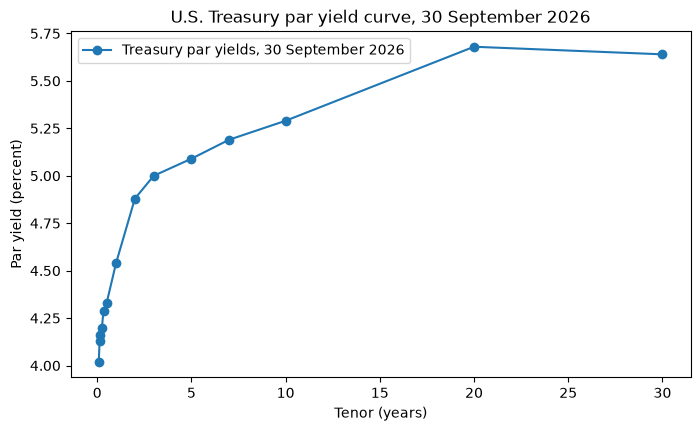

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
# one point per published tenor, joined by straight lines
ax.plot(real_curve["tenor_years"], real_curve["yield_pct"], marker="o", label="Treasury par yields, 30 September 2026")
ax.set_title("U.S. Treasury par yield curve, 30 September 2026")
ax.set_xlabel("Tenor (years)")
ax.set_ylabel("Par yield (percent)")
ax.legend()
plt.show()

* On that date the lowest yield on the curve was 4.02 percent, at 1 Mo, and the highest 5.68, at 20 Yr. The 30 Yr was 5.64.
* 6 points crowd into the first year at the left; the last two are ten years apart. A yield between any two of these points has to come from a line drawn between them.
* This describes the published figures on one date. It says nothing about why the curve had this shape or where it goes next.

**Excel side by side: the chart.** Tested in Excel: put `tenor_years` and `yield_pct` headers in A1:B1, the fourteen tenors in years in A2:A15 (type `=1/12` for `1 Mo`, `=1.5/12` for `1.5 Month`, and so on) and the yields in B2:B15. Select A1:B15 and choose Insert, Scatter with Straight Lines and Markers. Excel draws one series, named `yield_pct`, with the tenors as its x values, placed at their distances in years, as in the chart above. The chart type called **Line** does something else with the same selection (tested): it draws the tenor column as a second line, and it places the fourteen points evenly across the axis, as if 1 month to 1.5 months were as far apart as 20 years to 30. For a curve, use Scatter.

## 11.2 Linear Interpolation by Hand

A bond with 6.4 years left. The curve has no 6.4-year point. The two tenors around it are 5 years and 7 years, so draw a straight line between those two points and read it at 6.4.

The line rises from the 5-year yield to the 7-year yield over 2 years. 6.4 years is 1.4 years along, so it is 1.4 / 2 = 0.7 of the way:

yield at 6.4 = yield at 5 + (6.4 - 5) / (7 - 5) x (yield at 7 - yield at 5)

Q. Interpolate the curve at 6.4 years by hand.

In [12]:
tenor = 6.4

# the two published points around 6.4 years
left_tenor, right_tenor = 5, 7
left_yield, right_yield = curve_row["5 Yr"], curve_row["7 Yr"]

# how far along the line 6.4 years is, from 0 at the left point to 1 at the right
weight = (tenor - left_tenor) / (right_tenor - left_tenor)
yield_at_tenor = left_yield + weight * (right_yield - left_yield)
print(f"{weight:.1f} of the way from {left_yield:.2f} to {right_yield:.2f}: {yield_at_tenor:.4f} percent at {tenor} years")

0.7 of the way from 5.09 to 5.19: 5.1600 percent at 6.4 years


* 0.7 of the way from 5.09 to 5.19 is **5.1600 percent**. Linear interpolation is a weighted average of the two neighbours, with more weight on the nearer one.

**Excel side by side: `FORECAST.LINEAR` on two points.** `FORECAST.LINEAR(x, known_y's, known_x's)` fits a straight line through the points it is given and reads it at x, and a straight line through two points is exactly the interpolation line. Tested in Excel: put 5 and 7 in A2:A3 and 5.09 and 5.19 in B2:B3. `=FORECAST.LINEAR(6.4,B2:B3,A2:A3)` returns 5.160000000000001, and the line written out, `=B2+(B3-B2)*(6.4-A2)/(A3-A2)`, returns 5.16: the same to the 15th decimal. Watch the argument order: the yields come **before** the tenors. Swapped, `=FORECAST.LINEAR(6.4,A2:A3,B2:B3)` returns 31.20, with no error, because Excel then reads the tenor as the thing to forecast.

For one maturity, you can pick the two tenors by eye. For a book of 200 bonds, the code has to find them.

Q. Which two tenors are around 6.4 years? Walk along the tenors until one is at least 6.4.

In [13]:
tenors = real_curve["tenor_years"].tolist()
labels = real_curve["label"].tolist()

# move right while the tenor is still short of 6.4 years: i stops at the first tenor at or beyond it
i = 0
while tenors[i] < tenor:
    i += 1
print(f"{tenor} years lies between {labels[i - 1]} and {labels[i]}, positions {i - 1} and {i} in the list")

6.4 years lies between 5 Yr and 7 Yr, positions 9 and 10 in the list


* Between `5 Yr` and `7 Yr`, positions 9 and 10 counting from 0. The loop is the bracket search the module's function uses.

**Excel side by side: `MATCH`.** `=MATCH(x, tenors, 1)` returns the position of the largest tenor that is less than or equal to x, in a list sorted from smallest to largest. Tested in Excel with the fourteen tenors in A2:A15: with 6.4 in D1, `=MATCH(D1,A2:A15,1)` returns 10, the position of 5 years counted from 1. `=INDEX(A2:A15,MATCH(D1,A2:A15,1))` returns 5 and the same with `+1` after the `MATCH` returns 7: the bracket.

## 11.3 `interpolate_yield`, with Flat Ends and a Check That the Tenors Ascend

Three decisions go into the docstring before any code:

1. **Units.** Tenors in years, yields in percent, the result in percent: the same units as the course's `yield_pct` column.
2. **The ends.** Below the first tenor the function returns the first yield, and beyond the last tenor the last yield. This is **flat extrapolation**, the simplest rule, and the same as `numpy.interp`. Extending the end line instead would invent a slope the curve does not show.
3. **The check.** The tenors must ascend, each larger than the one before, or the bracket search is meaningless. The function raises `ValueError` rather than return a number from a jumbled curve.

Q. Add `interpolate_yield` to the end of `bondmath.py`. Read it before you run the cell.

In [14]:
%%writefile -a bondmath.py


def interpolate_yield(tenor_years: float, curve_tenors: list[float], curve_yields_pct: list[float]) -> float:
    """Yield at any tenor by straight-line interpolation on a curve, flat beyond its ends.

    Units: tenors in years, yields in percent; the result is in percent.
    Convention: linear in yield against tenor between the two curve points around tenor_years. Below
    the first tenor the first yield is used, above the last tenor the last yield (as numpy.interp).
    Raises ValueError if the lists differ in length, are empty, or the tenors do not ascend.
    """
    # stop on a curve the function cannot read
    if len(curve_tenors) != len(curve_yields_pct) or len(curve_tenors) == 0:
        raise ValueError("curve_tenors and curve_yields_pct must be non-empty and the same length")
    for i in range(1, len(curve_tenors)):
        if curve_tenors[i] <= curve_tenors[i - 1]:
            raise ValueError(f"curve tenors must ascend: {curve_tenors[i - 1]} then {curve_tenors[i]}")
    # flat beyond the ends
    if tenor_years <= curve_tenors[0]:
        return curve_yields_pct[0]
    if tenor_years >= curve_tenors[-1]:
        return curve_yields_pct[-1]
    # find the two tenors around tenor_years
    i = 1
    while curve_tenors[i] < tenor_years:
        i += 1
    left_tenor, right_tenor = curve_tenors[i - 1], curve_tenors[i]
    left_yield, right_yield = curve_yields_pct[i - 1], curve_yields_pct[i]
    # move along the straight line between them
    slope = (right_yield - left_yield) / (right_tenor - left_tenor)
    return left_yield + slope * (tenor_years - left_tenor)

Appending to bondmath.py


* `Appending to bondmath.py`. The docstring states the units, the convention, the flat ends, and what raises.
* The checks come first: two lists of the same, non-zero length, and tenors that ascend. `range(1, len(curve_tenors))` compares each tenor with the one before it.
* Then the flat ends, then the bracket search from section 11.2, then the straight line. The two names `left_` and `right_` make the formula read like the one you did by hand.

Q. Reload the module and interpolate the curve at 6.4 years.

In [15]:
importlib.reload(bondmath)

real_tenors = real_curve["tenor_years"].tolist()
real_yields = real_curve["yield_pct"].tolist()

from_module = bondmath.interpolate_yield(6.4, real_tenors, real_yields)
print(f"interpolate_yield at 6.4 years: {from_module:.4f} percent")
# the module must give exactly the hand answer
assert from_module == yield_at_tenor

interpolate_yield at 6.4 years: 5.1600 percent


* 5.1600 percent, exactly the hand answer.

Q. And on a published tenor, below the first tenor, and beyond the last?

In [16]:
for t in [10, 0.02, 40]:
    print(f"{t:>5} years: {bondmath.interpolate_yield(t, real_tenors, real_yields):.2f} percent")

   10 years: 5.29 percent
 0.02 years: 4.02 percent
   40 years: 5.64 percent


* On the 10-year tenor the function returns the published 5.29. At 0.02 years, about a week, it returns the 1-month yield, 4.02, and at 40 years the 30-year yield, 5.64: flat beyond both ends.

Q. What does it do with tenors that are out of order?

In [17]:
try:
    # a curve typed with 3 years before 2 years
    bondmath.interpolate_yield(4, [1, 3, 2], [3.7, 3.9, 3.8])
except ValueError as error:
    print(f"ValueError: {error}")

ValueError: curve tenors must ascend: 3 then 2


* It refuses, and says where: `curve tenors must ascend: 3 then 2`. Section 11.4 shows why that check earns its place.

Q. Add the four tests.

In [18]:
%%writefile -a test_bondmath.py


# The invented curve the holdings file was built on, at ten tenors: round(3.55 + 1.05 x (1 - exp(-T / 7)), 3)
CURVE_TENORS = [0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30]
CURVE_YIELDS_PCT = [3.587, 3.622, 3.69, 3.811, 3.916, 4.086, 4.214, 4.348, 4.54, 4.586]


def test_on_a_tenor_returns_its_yield():
    for tenor, yield_pct in zip(CURVE_TENORS, CURVE_YIELDS_PCT):
        assert bondmath.interpolate_yield(tenor, CURVE_TENORS, CURVE_YIELDS_PCT) == pytest.approx(yield_pct, abs=1e-12)


def test_matches_numpy_interp():
    import numpy as np  # numpy is in the course requirements; bondmath itself does not use it

    for tenor in (0.1, 0.92, 1.5, 4.0, 6.4, 8.75, 15.0, 29.9, 35.0):
        expected = float(np.interp(tenor, CURVE_TENORS, CURVE_YIELDS_PCT))
        assert bondmath.interpolate_yield(tenor, CURVE_TENORS, CURVE_YIELDS_PCT) == pytest.approx(expected, abs=1e-12)


def test_flat_beyond_the_ends():
    # below the first tenor: the first yield; above the last: the last yield
    assert bondmath.interpolate_yield(0.1, CURVE_TENORS, CURVE_YIELDS_PCT) == 3.587
    assert bondmath.interpolate_yield(40, CURVE_TENORS, CURVE_YIELDS_PCT) == 4.586


def test_raises_when_tenors_not_ascending():
    with pytest.raises(ValueError):
        bondmath.interpolate_yield(4, [1, 3, 2], [3.7, 3.9, 3.8])

Appending to test_bondmath.py


* The tests use the **invented** ten-tenor curve, typed in as `CURVE_TENORS` and `CURVE_YIELDS_PCT`. Section 11.5 introduces it, and the Git section commits the file those ten points come from.
* `test_on_a_tenor_returns_its_yield`: on each of the ten tenors the function returns that tenor's yield.
* `test_matches_numpy_interp`: at nine tenors, inside and outside the curve, it agrees with `numpy.interp` to 1e-12, the tolerance in the course's table. numpy is imported inside the test, because `bondmath` itself does not use it.
* `test_flat_beyond_the_ends` and `test_raises_when_tenors_not_ascending`: the two decisions of the docstring.

Q. Run the tests.

In [19]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

................................                                         [100%]
32 passed in 1.18s



* `32 passed`: the 28 from weeks 1 and 2 and today's 4.

## 11.4 The Same with `numpy.interp`

numpy, which Course 1 taught, has linear interpolation built in: `np.interp(x, tenors, yields)`. It takes one tenor or a whole array of them.

Q. Does `numpy.interp` agree with `interpolate_yield` on the real curve, inside and outside it?

In [20]:
import numpy as np

check_tenors = [0.02, 0.5, 2.5, 6.4, 8.5, 15, 25, 40]
comparison = pd.DataFrame({"tenor_years": check_tenors})
comparison["interpolate_yield"] = [bondmath.interpolate_yield(t, real_tenors, real_yields) for t in check_tenors]
# np.interp takes the whole list of tenors at once
comparison["np_interp"] = np.interp(check_tenors, real_tenors, real_yields)
comparison["difference"] = comparison["interpolate_yield"] - comparison["np_interp"]

assert comparison["difference"].abs().max() < 1e-12
comparison

,tenor_years,interpolate_yield,np_interp,difference
0,0.02,4.020,4.020,0.0
1,0.50,4.330,4.330,0.0
2,2.50,4.940,4.940,0.0
3,6.40,5.160,5.160,0.0
4,8.50,5.240,5.240,0.0
5,15.00,5.485,5.485,0.0
6,25.00,5.660,5.660,0.0
7,40.00,5.640,5.640,0.0


* Every tenor agrees, the two ends included: `numpy.interp` is flat beyond the ends as well. The point of writing the function yourself is to know exactly what the number means, and to say so in a docstring.

Q. One difference. What does `numpy.interp` do with the jumbled curve from section 11.3?

In [21]:
# the same curve, with 3 years before 2 years
print(f"np.interp at 4 years on a jumbled curve: {np.interp(4, [1, 3, 2], [3.7, 3.9, 3.8])}")

np.interp at 4 years on a jumbled curve: 3.8


* It returns 3.8 with no error and no warning. numpy's documentation for `interp` says the tenors are expected to increase but that this is not enforced, and that if they do not, the results are meaningless (numpy 2.5.3, the Warnings section of `numpy.interp`, https://numpy.org/doc/stable/reference/generated/numpy.interp.html). The check belongs to whoever calls it. `interpolate_yield` makes the check, so a curve typed in the wrong order stops instead of answering.

## 11.5 The Curve the Holdings Were Built On

The holdings file's yields were not built on the real Treasury curve. The program that generated the file used a smooth **invented** curve, given in the course's `DATA.md`:

yield in percent = 3.55 + 1.05 x (1 - exp(-T / 7)), with T the years to maturity

and added each bond's spread to it. Course 2 keeps that curve at ten tenors, rounded to 3 decimals as the generator rounded it, in `course2_treasury_curve.csv`. **This is the curve days 12 to 14 measure spreads from**, and it reproduces the holdings file's `oas` column. The real curve of section 11.1 is never used for a spread.

Q. Copy the invented curve into the work folder and read it.

In [22]:
# copy the curve file into the work folder, from the same place as the reference files: today's Git step commits it
if on_github:
    urllib.request.urlretrieve(RAW_DATA + "course2_treasury_curve.csv", work / "course2_treasury_curve.csv")
else:
    shutil.copy(local_data / "course2_treasury_curve.csv", work / "course2_treasury_curve.csv")

invented = pd.read_csv("course2_treasury_curve.csv")
invented_tenors = invented["tenor_years"].tolist()
invented_yields = invented["yield_pct"].tolist()

import math

# each point is the formula at its tenor, rounded to 3 decimals: stop here if one is not
formula_points = [round(3.55 + 1.05 * (1 - math.exp(-t / 7)), 3) for t in invented_tenors]
assert formula_points == invented_yields
invented

,tenor_years,yield_pct
0,0.25,3.587
1,0.50,3.622
2,1.00,3.690
3,2.00,3.811
4,3.00,3.916
5,5.00,4.086
6,7.00,4.214
7,10.00,4.348
8,20.00,4.540
9,30.00,4.586


* Ten tenors from 0.25 to 30 years, 3.587 percent to 4.586 percent, each equal to the formula rounded to 3 decimals.
* In `holdings.csv` the shortest bond has 1.01 years left and the longest 29.90, so every holdings bond sits inside the table. It starts at 0.25 years because the October project book of Course 1 holds a bond with 0.92 years left. Flat extrapolation stays in the function for any bond outside the table.
* At 6.4 years the invented curve gives 4.1756 percent with `interpolate_yield`.

Q. Chart the two curves on one set of axes.

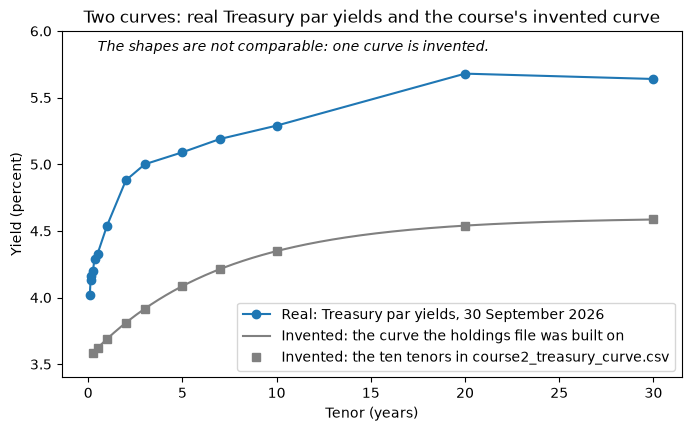

In [23]:
# the invented curve's formula, drawn smooth on a fine grid of tenors
fine = np.linspace(0.25, 30, 300)
smooth_curve = 3.55 + 1.05 * (1 - np.exp(-fine / 7))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(real_curve["tenor_years"], real_curve["yield_pct"], marker="o", label="Real: Treasury par yields, 30 September 2026")
ax.plot(fine, smooth_curve, color="grey", label="Invented: the curve the holdings file was built on")
ax.plot(invented_tenors, invented_yields, "s", color="grey", label="Invented: the ten tenors in course2_treasury_curve.csv")
# the sentence the chart must carry
ax.text(0.5, 5.85, "The shapes are not comparable: one curve is invented.", fontsize=10, style="italic")
# room above the curves for that sentence
ax.set_ylim(3.4, 6.0)
ax.set_title("Two curves: real Treasury par yields and the course's invented curve")
ax.set_xlabel("Tenor (years)")
ax.set_ylabel("Yield (percent)")
ax.legend(loc="lower right")
plt.show()

* **The shapes are not comparable, because one curve is invented.** The invented curve was written as a formula to give the course's synthetic bonds believable yields; it was never fitted to the Treasury figures. The chart sets the two side by side only to show which file is which.
* The invented curve is smooth: it rises fastest at the short end and flattens as the tenor grows. The squares are the only points of it the course keeps in a file.

## 11.6 How Far the Straight Line Is from the Smooth Curve

The ten squares sit on the smooth curve. Between them, `interpolate_yield` draws straight lines. Where the curve bends, a straight line cannot follow it.

Q. Read the invented curve every 0.01 years, from the formula and from the straight lines through the ten points. How far apart are they, in basis points?

In [24]:
# 2,976 tenors, 0.01 years apart, from 0.25 to 30 years
grid = np.linspace(0.25, 30, 2976)
from_formula = 3.55 + 1.05 * (1 - np.exp(-grid / 7))
from_lines = np.array([bondmath.interpolate_yield(t, invented_tenors, invented_yields) for t in grid])

# the formula minus the straight line, in basis points: 1 percent is 100 basis points
gap_bp = (from_formula - from_lines) * 100
print(f"largest gap: {gap_bp.max():.2f} bp, at {grid[gap_bp.argmax()]:.2f} years")
print(f"average gap over the grid: {gap_bp.mean():.2f} bp")

largest gap: 3.33 bp, at 14.39 years
average gap over the grid: 1.01 bp


* The straight lines sit **below** the smooth curve almost everywhere, by up to **3.33 basis points**, at 14.39 years, and by 1.01 bp on average over the grid. A curve that rises ever more slowly bends above the straight line drawn between any two of its points.
* The largest gap is between 10 and 20 years, the widest space between two tenors where the curve still bends. At the ten tenors themselves the gap is only the rounding to 3 decimals, at most 0.05 bp.

Q. Chart the gap against the tenor.

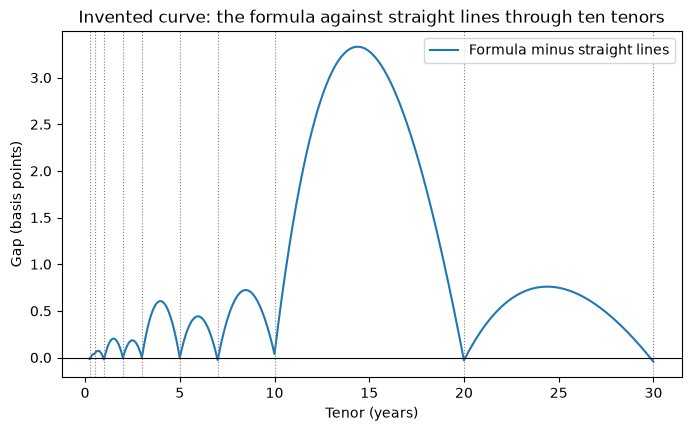

In [25]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(grid, gap_bp, label="Formula minus straight lines")
# a dotted line at each of the ten tenors, where the two agree
for t in invented_tenors:
    ax.axvline(t, color="grey", linestyle=":", linewidth=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Invented curve: the formula against straight lines through ten tenors")
ax.set_xlabel("Tenor (years)")
ax.set_ylabel("Gap (basis points)")
ax.legend()
plt.show()

* A hump between every pair of tenors, touching zero at each dotted line. The humps grow with the space between tenors: small at the short end, where the tenors are close, largest between 10 and 20 years.
* So **the interpolation choice moves the number.** A bond's spread is its yield minus the curve's yield at its maturity, and day 12 measures what these few basis points do to each bond's spread.

## Excel Side by Side

Today's Excel, in one place. Every formula was tested in Excel. The curve is in two columns: tenors in years in A2:A15, yields in B2:B15, and the tenor to read in D1.

| Job | Python | Excel (tested) | Excel returns |
| --- | --- | --- | --- |
| A straight line through two points | `left + weight * (right - left)` | `=FORECAST.LINEAR(6.4,B2:B3,A2:A3)`, with 5 and 7 in A2:A3 | 5.160000000000001 |
| The same, written out | the same | `=B2+(B3-B2)*(6.4-A2)/(A3-A2)` | 5.16 |
| Arguments swapped | | `=FORECAST.LINEAR(6.4,A2:A3,B2:B3)` | 31.20, no error |
| The bracket's position | the `while` loop of 11.2 | `=MATCH(D1,A2:A15,1)`, 6.4 in D1 | 10 |
| The bracket's tenors | `tenors[i - 1]`, `tenors[i]` | `=INDEX(A2:A15,MATCH(D1,A2:A15,1))` and `...+1)` | 5 and 7 |
| Any tenor inside the curve | `bondmath.interpolate_yield(6.4, real_tenors, real_yields)` | the formula below, 6.4 in D1 | 5.160000000000001 |
| Below the first tenor | flat: 4.02 | the formula below, 0.02 in D1 | `#N/A` |
| At or beyond the last tenor | flat: 5.64 | the formula below, 30 or 35 in D1 | `#REF!` |
| A chart of the curve | `ax.plot(tenors, yields, marker="o")` | select A1:B15, Insert, Scatter with Straight Lines and Markers | one series, tenors at their distances |

The formula, with the bracket found by `MATCH` and the two points handed to `FORECAST.LINEAR` by `INDEX`:

```
=FORECAST.LINEAR(D1,INDEX(B2:B15,MATCH(D1,A2:A15,1)):INDEX(B2:B15,MATCH(D1,A2:A15,1)+1),INDEX(A2:A15,MATCH(D1,A2:A15,1)):INDEX(A2:A15,MATCH(D1,A2:A15,1)+1))
```

It reads: find the position of the tenor at or below D1; take the yields at that position and the next as the known y's, and the two tenors as the known x's; forecast D1 on the line through them.

It does not extrapolate. Below the first tenor `MATCH` finds nothing and returns `#N/A`. At the last tenor or beyond, the bracket's second point would be the row after the table, and `INDEX` returns `#REF!`. So use it strictly inside the curve, where it equals `interpolate_yield`; the flat ends are the Python function's job. On the invented curve, with the ten points in A2:B11 and the ranges ending at row 11, the same formula returns 4.1756 at 6.4 years, `#N/A` at 0.1, and `#REF!` at 30.

To try it: type the curve of 30 September 2026 into a blank sheet as section 11.1 describes, put 6.4 in D1 and the formula in E1, then change D1 and watch the bracket move.

Q. Does `interpolate_yield` agree with what Excel returned, on both curves?

In [26]:
# what Excel's formula returned (tested in Excel): tenor in years -> yield in percent
excel_real = {6.4: 5.160000000000001, 0.5: 4.330000000000001, 2.5: 4.9399999999999995, 8.5: 5.24, 15: 5.484999999999999, 25: 5.66, 10: 5.29}
excel_invented = {0.25: 3.587, 0.92: 3.6791199999999993, 6.4: 4.1756, 10.0: 4.348, 15.0: 4.444, 29.5: 4.583700000000001}

rows = []
for curve_name, excel_values, tenors_, yields_ in [("real, 30 September 2026", excel_real, real_tenors, real_yields),
                                                  ("invented", excel_invented, invented_tenors, invented_yields)]:
    for t, excel_value in excel_values.items():
        python_value = bondmath.interpolate_yield(t, tenors_, yields_)
        rows.append({"curve": curve_name, "tenor_years": t, "excel": excel_value, "python": python_value,
                     "difference": python_value - excel_value})

answer_key = pd.DataFrame(rows)
assert answer_key["difference"].abs().max() < 1e-12, "a tenor differs from Excel"
print(f"{len(answer_key)} tenors, largest difference {answer_key['difference'].abs().max():.1e} percent")
answer_key

13 tenors, largest difference 8.9e-16 percent


,curve,tenor_years,excel,python,difference
0,"real, 30 September 2026",6.40,5.16000,5.16000,-8.881784e-16
1,"real, 30 September 2026",0.50,4.33000,4.33000,-8.881784e-16
2,"real, 30 September 2026",2.50,4.94000,4.94000,0.000000e+00
3,"real, 30 September 2026",8.50,5.24000,5.24000,0.000000e+00
4,"real, 30 September 2026",15.00,5.48500,5.48500,0.000000e+00
5,"real, 30 September 2026",25.00,5.66000,5.66000,0.000000e+00
6,"real, 30 September 2026",10.00,5.29000,5.29000,0.000000e+00
7,invented,0.25,3.58700,3.58700,0.000000e+00
8,invented,0.92,3.67912,3.67912,8.881784e-16
9,invented,6.40,4.17560,4.17560,0.000000e+00


* All 13 agree, the largest difference 8.9e-16 percent: the last binary digit, from adding in a different order. Excel and Python draw the same straight line.

## Save the Day with Git

First, commit today's work. Then today's Git step: **commit the data file the tests' numbers come from.** The tests type ten points of the invented curve; the file `course2_treasury_curve.csv` is where those ten points live. Committing the file beside the tests keeps the source of every number in the same record.

Q. What has changed since the start of the day?

In [27]:
# the files that changed, then how many lines in each
!git -C "{work}" status --short
!git -C "{work}" diff --stat

 M bondmath.py
 M test_bondmath.py
?? bondmath_excel_reference.csv
?? bondmath_excel_reference_tvm.csv
?? course2_treasury_curve.csv


 bondmath.py      | 30 ++++++++++++++++++++++++++++++
 test_bondmath.py | 29 +++++++++++++++++++++++++++++
 2 files changed, 59 insertions(+)


* ` M` beside both files: 30 lines added to `bondmath.py` and 29 to `test_bondmath.py`.
* The `??` lines are untracked: the two Excel reference files and today's curve file.

Q. Commit today's work.

In [28]:
# the subject says what, the body says why
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" commit -q -m "Add interpolate_yield: linear between tenors, flat beyond the ends" -m "Week 3 reads a curve yield at each bond's own maturity; the tests check it against numpy.interp."
!git -C "{work}" log --oneline

6a0a0a2 Add interpolate_yield: linear between tenors, flat beyond the ends
164022d Start of day 11: bondmath.py and test_bondmath.py as day 10 left them


* Two commits: the start of day 11, and today's work.

Q. Before committing the curve file, check it holds exactly the ten points the tests type.

In [29]:
# import the test file as a module, to read the two lists it types
import test_bondmath

assert test_bondmath.CURVE_TENORS == invented_tenors
assert test_bondmath.CURVE_YIELDS_PCT == invented_yields
print(f"The tests' {len(test_bondmath.CURVE_TENORS)} points equal course2_treasury_curve.csv")

The tests' 10 points equal course2_treasury_curve.csv

* The same ten tenors and yields. The file is the source; the test is a copy that runs without it.

Q. Commit the curve file, and show the last commit with the files it changed.

In [30]:
# commit the data file, then show the last commit and its files
!git -C "{work}" add course2_treasury_curve.csv
!git -C "{work}" commit -q -m "Add the invented curve file the interpolation tests take their ten points from"
!git -C "{work}" log --stat -1

commit 33d50c10c6d8564ea8298323c43d64368917d307
Author: Course Student <student@example.com>
Date:   Sun Oct 4 15:53:13 2026 -0400

    Add the invented curve file the interpolation tests take their ten points from

 course2_treasury_curve.csv | 11 +++++++++++
 1 file changed, 11 insertions(+)


* `git log --stat -1` shows one commit, the last one (`-1`), and under its message the files it changed (`--stat`): one file, its lines all added.
* Three commits in all. The data file is now in the record next to the tests that rely on it: a later reader can see exactly which curve the tests were written against.

## Bring It Home

Now bring today's work into your own `my_bondmath` folder. Open a PowerShell terminal in VS Code (Terminal, New Terminal), with the course's `.venv` active.

**Step 1.** Go to your folder.

```powershell
Set-Location "$HOME\projects\my_bondmath"
```

**Step 2.** Paste today's code at the end of your two files. In `bondmath.py`, leave two blank lines after the last function and paste the code of the `%%writefile -a bondmath.py` cell of section 11.3, without its first line. In `test_bondmath.py`, do the same with the `%%writefile -a test_bondmath.py` cell. Save both files.

**Step 3.** Copy the curve file in from the course repo's `data` folder.

```powershell
Copy-Item "$HOME\projects\python-fixed-income\data\course2_treasury_curve.csv" .
```

**Step 4.** Run the tests.

```powershell
python -m pytest -q
```

```
................................                                         [100%]
32 passed in 0.10s
```

If you added the exercise functions of earlier days with their tests, you will see more. If a test fails, compare your file with the code in the cells.

**Step 5.** Read the change, commit it, then commit the curve file and look at that commit.

```powershell
git diff --stat
git add bondmath.py test_bondmath.py
git commit -m "Add interpolate_yield: linear between tenors, flat beyond the ends" -m "Week 3 reads a curve yield at each bond's own maturity; the tests check it against numpy.interp."
git add course2_treasury_curve.csv
git commit -m "Add the invented curve file the interpolation tests take their ten points from"
git log --stat -1
```

**If your copy has fallen behind or broken**, the setup cell of this notebook wrote the full start-of-day files. Replace yours with them, run `git diff` to see exactly what changed, and carry on from step 2.

**In Colab**, download `bondmath.py`, `test_bondmath.py`, and `course2_treasury_curve.csv` from the work folder under `/tmp` in the file browser.

## You Can Now

* Read a curve as tenors and yields, and turn Treasury's column labels into years.
* Interpolate between two tenors by hand, and find the bracket with a loop or with Excel's `MATCH`.
* Use `interpolate_yield`: linear between tenors, flat beyond the ends, and a stop on tenors out of order.
* Check it against `numpy.interp`, and say what `numpy.interp` leaves to you.
* Interpolate in Excel with `FORECAST.LINEAR` on an `INDEX`/`MATCH` bracket, strictly inside the curve, and chart a curve as a Scatter.
* Tell the real Treasury curve, described only, from the invented curve the holdings were built on.
* Say how far straight lines sit from a smooth curve, and where the gap is largest.
* Commit a data file next to the tests that rely on it, and read a commit with `git log --stat -1`.

Tomorrow, day 12, reads the invented curve at each holdings bond's own maturity and computes its spread to the curve, `spread_to_curve_bp`: first with the curve's formula, which reproduces the file's `oas` column exactly, then with today's straight lines, and the gap of section 11.6 shows up in every spread.

## Exercises

The exercises use the real Treasury file: a second date, the labels, and an assistant's function. They describe the data and make no statement about where yields go.

Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It reads the Treasury file, builds the curve of 30 September 2026 in years, and defines `check`, a small function that marks your answers.

In [31]:
import numpy as np

treasury = pd.read_csv(data_folder + "treasury_par_yields.csv", index_col="date")
curve_row = treasury.loc["2026-09-30"]

# Treasury's labels and the years each stands for, as in section 11.1
TENOR_YEARS = {"1 Mo": 1 / 12, "1.5 Month": 1.5 / 12, "2 Mo": 2 / 12, "3 Mo": 3 / 12, "4 Mo": 4 / 12, "6 Mo": 6 / 12,
               "1 Yr": 1, "2 Yr": 2, "3 Yr": 3, "5 Yr": 5, "7 Yr": 7, "10 Yr": 10, "20 Yr": 20, "30 Yr": 30}
real_tenors = [TENOR_YEARS[label] for label in curve_row.index]
real_yields = curve_row.tolist()


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. The last date in the file is 2026-10-02. With `bondmath.interpolate_yield`, interpolate that date's curve at 6.4 years and at 15 years. Store the two yields in percent in **ex1_6_4** and **ex1_15**, and the change at 6.4 years from 30 September 2026 to 2026-10-02, in basis points, in **ex1_change_bp**.

In [32]:
ex1_6_4 = ...
ex1_15 = ...
ex1_change_bp = ...

In [33]:
check("Exercise 1 yield at 6.4 years", ex1_6_4, 5.137)
check("Exercise 1 yield at 15 years", ex1_15, 5.475)
check("Exercise 1 change at 6.4 years in bp", ex1_change_bp, -2.3000000000000576)

Exercise 1 yield at 6.4 years: not attempted yet
Exercise 1 yield at 15 years: not attempted yet
Exercise 1 change at 6.4 years in bp: not attempted yet


### Exercise 2

Q. Add a function to your module. `tenor_label_to_years(label)` turns one of Treasury's labels, such as `"3 Mo"`, `"1.5 Month"`, or `"10 Yr"`, into years. Write the docstring first: units and convention, and what raises. Raise `ValueError` for a unit that is not `Mo`, `Month`, or `Yr`. Then add a test to `test_bondmath.py`, called `test_tenor_label_to_years_cases`, with hand cases for `"1 Mo"`, `"1.5 Month"`, `"3 Mo"`, and `"30 Yr"`, and a `pytest.raises` case for `"3 Wk"`. Run pytest. Store `bondmath.tenor_label_to_years("3 Mo")` in **ex2_three_months**, and the number of the file's 14 labels that come to less than one year in **ex2_under_one_year**.

Write the function in the cell that starts with `%%writefile -a bondmath.py` and the test in the one that starts with `%%writefile -a test_bondmath.py`, and run each of those cells once. Then reload the module.

In [34]:
%%writefile -a bondmath.py


# Exercise 2: write tenor_label_to_years(label) below this line

Appending to bondmath.py


In [35]:
%%writefile -a test_bondmath.py


# Exercise 2: write test_tenor_label_to_years_cases() below this line

Appending to test_bondmath.py


In [36]:
# run pytest, reload the module, then call your function
ex2_three_months = ...
ex2_under_one_year = ...

In [37]:
check("Exercise 2 3 Mo in years", ex2_three_months, 0.25)
check("Exercise 2 labels under one year", ex2_under_one_year, 6)

Exercise 2 3 Mo in years: not attempted yet
Exercise 2 labels under one year: not attempted yet


### Exercise 3: AI check

You ask an AI assistant for a function that reads a yield at any tenor straight from a row of the Treasury file, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Yield in percent at tenor_years on one date of the Treasury par yield file, by straight-line
interpolation between the published tenors, flat beyond the first and last tenor.

Units: tenor_years in years; row is one row of treasury_par_yields.csv as a pandas Series, its labels
Treasury's column names ("1 Mo", "1.5 Month", ..., "30 Yr") and its values yields in percent.
Convention: each label is turned into years, months as twelfths of a year, before interpolating.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug: a convention error.

In [38]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def assistant_treasury_yield_at(row, tenor_years):
    """Yield in percent at tenor_years on one date of the Treasury par yield file, by straight-line
interpolation between the published tenors, flat beyond the first and last tenor.

Units: tenor_years in years; row is one row of treasury_par_yields.csv as a pandas Series, its labels
Treasury's column names ("1 Mo", "1.5 Month", ..., "30 Yr") and its values yields in percent.
Convention: each label is turned into years, months as twelfths of a year, before interpolating.
    """
    tenors, yields = [], []
    for label, yield_pct in row.dropna().items():
        number = float(label.split()[0])
        # Treasury writes some short tenors as months
        if label.endswith("Month"):
            number = number / 12
        tenors.append(number)
        yields.append(yield_pct)
    # sort by tenor, so numpy.interp gets its points in order
    points = sorted(zip(tenors, yields))
    return float(np.interp(tenor_years, [t for t, _ in points], [y for _, y in points]))

Q. Before you run the next cell: what should the function return at 6.4 years on 30 September 2026? Section 11.2 has the number.

In [39]:
print(f"The assistant's yield at 6.4 years: {assistant_treasury_yield_at(curve_row, 6.4):.4f} percent")

The assistant's yield at 6.4 years: 4.6740 percent


Q. Test the function against what Excel's formula returned before you trust it.

In [40]:
# the test, written from Excel before the code is trusted: FORECAST.LINEAR with the MATCH bracket on the curve of
# 30 September 2026, as Excel returned it (tested in Excel), for each tenor in years
excel_forecast = {6.4: 5.160000000000001, 0.5: 4.330000000000001, 2.5: 4.9399999999999995, 8.5: 5.24, 15: 5.484999999999999, 25: 5.66, 10: 5.29}

for tenor, excel_value in excel_forecast.items():
    result = assistant_treasury_yield_at(curve_row, tenor)
    assert abs(result - excel_value) < 1e-9, f"{tenor} years: {result} against Excel's {excel_value}"

print("Every tenor matches Excel's FORECAST.LINEAR")

AssertionError: 6.4 years: 4.674 against Excel's 5.160000000000001

Q. The test stops on the first tenor that disagrees. Read its message, find the convention the code broke, and fix the function in the cell that defines it. Run that cell and the test again until the test prints that every tenor matches. Then store `assistant_treasury_yield_at(curve_row, 6.4)` in **ex3_6_4** and `assistant_treasury_yield_at(curve_row, 0.5)` in **ex3_0_5**.

In [41]:
# fix the function above and run the test again, then store the two answers
ex3_6_4 = ...
ex3_0_5 = ...

In [42]:
check("Exercise 3 yield at 6.4 years", ex3_6_4, 5.16)
check("Exercise 3 yield at 0.5 years", ex3_0_5, 4.33)

Exercise 3 yield at 6.4 years: not attempted yet
Exercise 3 yield at 0.5 years: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```